In [ ]:
# conda activate anndata

import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import tqdm as notebook_tqdm
import matplotlib.pyplot as plt

os.chdir("scRNA-seq")

In [ ]:
# Load data

adata = ad.read_h5ad("data/matrix_scvi_annotated.h5ad")
enriched_df = pd.read_csv("data/enriched_genes_bc_pval_cutoff_and_lfc>2.csv")

In [ ]:
# take top N enriched genes
n = 100
enriched_df = enriched_df.iloc[0:n]

In [ ]:
# get mean expression of CalTRAP enriched genes in each cell

enriched_inds = [adata.raw.var_names.get_loc(gene) for gene in enriched_df['ensg'].tolist() if gene in adata.raw.var_names]

# this version of the data is normalized and log-transformed, and contains full space of genes (not just HVGs used for clustering)
log2_normalized = adata.raw.X.copy() 
log2_normalized_csr = log2_normalized.tocsr()
adata.obs['mean_expr'] = np.mean(log2_normalized_csr[:, enriched_inds], axis=1)

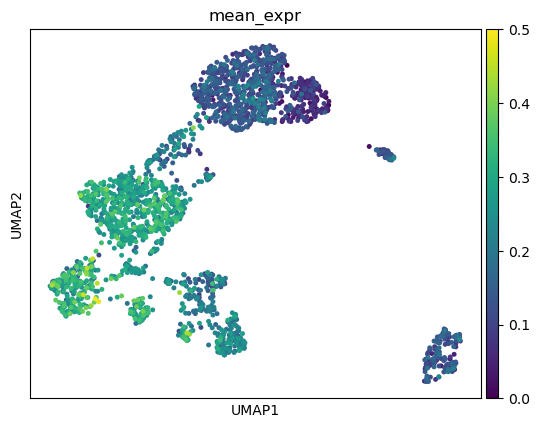

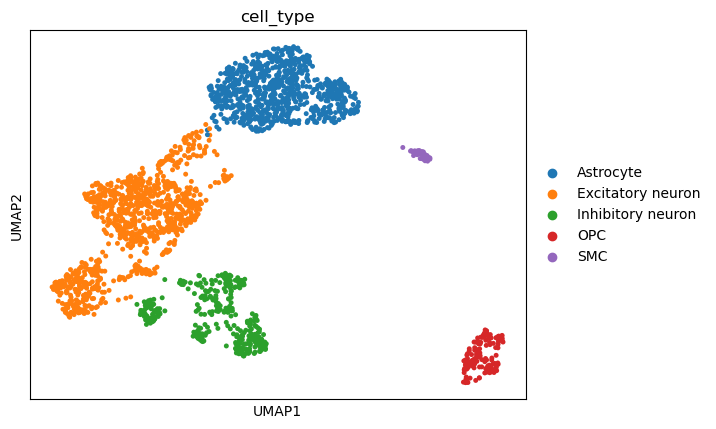

In [ ]:
# which cell types are most enriched in CalTRAP enriched genes?

sc.pl.umap(adata, color="mean_expr", cmap="viridis")
sc.pl.umap(adata, color=['cell_type'])

In [ ]:
# get relative mean expression of CalTRAP enriched genes per cell type

enriched_genes = [gene for gene in enriched_df['ensg'].tolist() if gene in adata.raw.var_names]
enriched_inds = [adata.raw.var_names.get_loc(gene) for gene in enriched_df['ensg'].tolist() if gene in adata.raw.var_names]

cell_types = list(set(adata.obs['cell_type']))
cell_type_expr = []
cell_type_stderr = []
for i in set(cell_types):
    cell_type_inds = np.where(adata.obs['cell_type'].isin([i]))[0].tolist()
    mean_expr = np.mean(log2_normalized_csr[cell_type_inds, :], axis=1)
    mean_expr_cal = np.mean(log2_normalized_csr[cell_type_inds, :][:, enriched_inds], axis=1)
    cal_vs_all = mean_expr_cal/mean_expr
    cal_vs_all_std = np.std(cal_vs_all)
    cell_type_stderr.append(cal_vs_all_std / np.sqrt(len(mean_expr)))
    cell_type_expr.append(np.mean(cal_vs_all))
    
cell_type_expr_index = cell_type_expr/np.max(cell_type_expr)

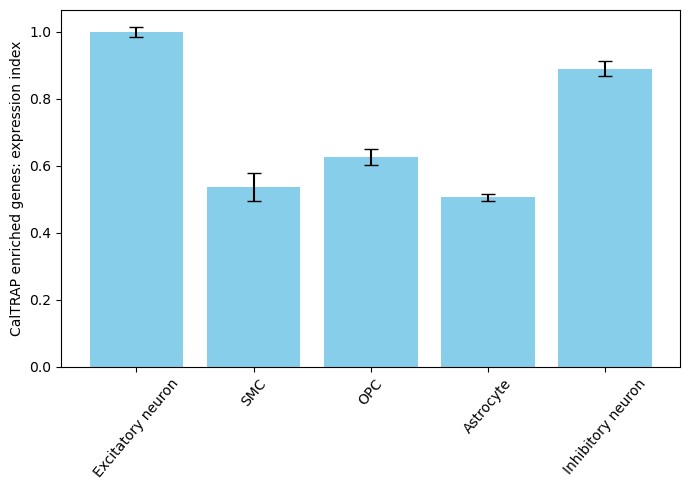

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(cell_types, cell_type_expr_index, yerr=cell_type_stderr, capsize=5, color="skyblue")
plt.xticks(rotation=50)
plt.ylabel("CalTRAP enriched genes: expression index")
plt.tight_layout()
plt.show()